# Homework 2: SPY on a 1-minute chart

The assignment has two parts: clean and analyze the data, then design a simple correlation trading rule. I’m using SPY and keeping the timeframe at 1 minute.

The idea is to check whether EMA, RSI, or an ATR-scaled move has a relationship with the next minute’s return. Then I turn that correlation into a long, short, or flat signal. This notebook stops at designing the rule; I haven’t evaluated trading performance here.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
ROOT = Path.cwd()
REBUILD = False
EMA_MINUTES = 20
RSI_MINUTES = 14
ATR_MINUTES = 14
CORR_MINUTES = 60
CORR_CUTOFF = 0.10

plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.18})

## a) Start with the trades

The downloads are huge, so I read one in chunks. Before making bars, I keep SPY trades with a valid time, positive price and size, and no correction/cancel flag. I also remove exact repeated records and prints that are late, out of sequence, or based on an average/reference price. Odd lots stay in: a small trade isn’t automatically a bad trade.

The session here is 9:30 to just before 16:00, New York time. The source timestamps are already Eastern time; they are not UTC. I check the file’s ordering rather than assuming the first row is always the earliest trade.

The chunk-reading code is in `spy_data.py` so the notebook doesn’t turn into a wall of file-handling code. The filter and trading calculations are below.

### Why 1 minute?

Five minutes is a choice, not a requirement. A full session gives 390 one-minute bars versus 78 five-minute bars. SPY has enough trades here to build a complete 1-minute series, so I’m starting there.

The trade-off is noise: a 1-minute move is small, and transaction costs could matter a lot if I later traded the signals. More bars also doesn’t mean more independent evidence. We still only have a few weeks of data.

Each bar is labeled by its **start**. The 9:30 bar covers 9:30:00–9:30:59.999…; its close is only known at 9:31. OHLC uses the actual trade order, volume is summed, and VWAP is total price × size divided by total size.

In [2]:
from spy_data import load_bars

bars, audit = load_bars(ROOT, rebuild=REBUILD)
print(f"{audit['raw_rows']:,} trade records → {audit['kept_rows']:,} kept")
print(f"{len(bars):,} minute bars across {audit['sessions']} sessions")
print(f"{bars.index[0].date()} to {bars.index[-1].date()}")
print("Identical downloads:", audit["duplicate_download"])
print("Times are New York time; no missing minute is filled in.")
display(bars.head().round(4))

audit_table = pd.DataFrame({"records removed": audit["removed"]})
audit_table.loc["kept", "records removed"] = audit["kept_rows"]
display(audit_table.astype(int))

10,757,236 trade records → 8,956,677 kept
5,850 minute bars across 15 sessions
2026-09-14 to 2026-10-02
Identical downloads: True
Times are New York time; no missing minute is filled in.


,open,high,low,close,volume,trades,vwap
bar_time,,,,,,,
2026-09-14 09:30:00-04:00,759.00,759.220,758.640,758.7500,678766.2575,6167,759.0545
2026-09-14 09:31:00-04:00,758.71,759.050,758.580,758.8250,335838.0429,3167,758.8315
2026-09-14 09:32:00-04:00,758.83,759.115,758.740,758.9880,210490.7037,2495,758.9535
2026-09-14 09:33:00-04:00,758.98,759.040,758.757,758.7799,86127.3297,1889,758.8884
2026-09-14 09:34:00-04:00,758.78,759.140,758.670,758.6850,111509.8833,1755,758.7949


,records removed
other_symbol,0
invalid_timestamp,0
duplicate_record,0
invalid_price_or_size,45
correction_or_cancel,108
stopped_trade,0
sale_condition,1799861
outside_session,545
kept,8956677


### What’s actually in the sample?

The files cover September 14 to October 2: 15 trading sessions, so about three trading weeks rather than two. I check the dates and minute counts before doing anything with the indicators.

I’m using the whole sample for descriptive analysis. There’s no training/test split or search for the most profitable settings in this assignment.

In [3]:
sessions = bars.index.normalize().unique().sort_values()
session_summary = bars.groupby(bars.index.normalize()).agg(
    minutes=("close", "size"), trades=("trades", "sum"),
    shares=("volume", "sum"), first_open=("open", "first"), last_close=("close", "last"))
session_summary["open to close (%)"] = 100 * (session_summary["last_close"] / session_summary["first_open"] - 1)
session_summary.index = session_summary.index.strftime("%b %d")
display(session_summary.round(3))

# Reset at the start of the day so an overnight move isn't a minute return.
within_day = bars.groupby(bars.index.normalize())["close"].pct_change(fill_method=None)
sample_returns = within_day.dropna() * 10_000
lagged_returns = within_day.groupby(bars.index.normalize()).shift(1) * 10_000
print(f"Mean: {sample_returns.mean():.3f} bps per minute")
print(f"Std:  {sample_returns.std():.3f} bps per minute")
print(f"Lag-1 correlation: {sample_returns.corr(lagged_returns):.3f}")

,minutes,trades,shares,first_open,last_close,open to close (%)
bar_time,,,,,,
Sep 14,390,528030,2.977365e+07,759.000,760.780,0.235
Sep 15,390,457491,2.499913e+07,760.117,757.360,-0.363
Sep 16,390,667529,4.110635e+07,759.500,754.095,-0.712
Sep 17,390,510412,3.001867e+07,763.140,762.660,-0.063
Sep 18,390,482535,2.961018e+07,761.310,761.640,0.043
Sep 21,390,569564,3.496195e+07,766.270,773.520,0.946
Sep 22,390,425243,2.209527e+07,773.980,773.360,-0.080
Sep 23,390,577462,3.216321e+07,772.790,767.750,-0.652
Sep 24,390,562622,2.962045e+07,764.065,767.250,0.417


Mean: -0.015 bps per minute
Std:  2.549 bps per minute
Lag-1 correlation: 0.049


### How noisy are the minute returns?

These two plots use all 15 sessions. Returns are in basis points: 1 bp is 0.01%. The histogram zooms to the middle 99% so a few tails don’t squash everything else; those tails stay in the calculations.

The second plot separates the clock-time pattern from the overnight gaps. The counts in the cleaning table are sequential: each record is counted under the first rule that removes it.

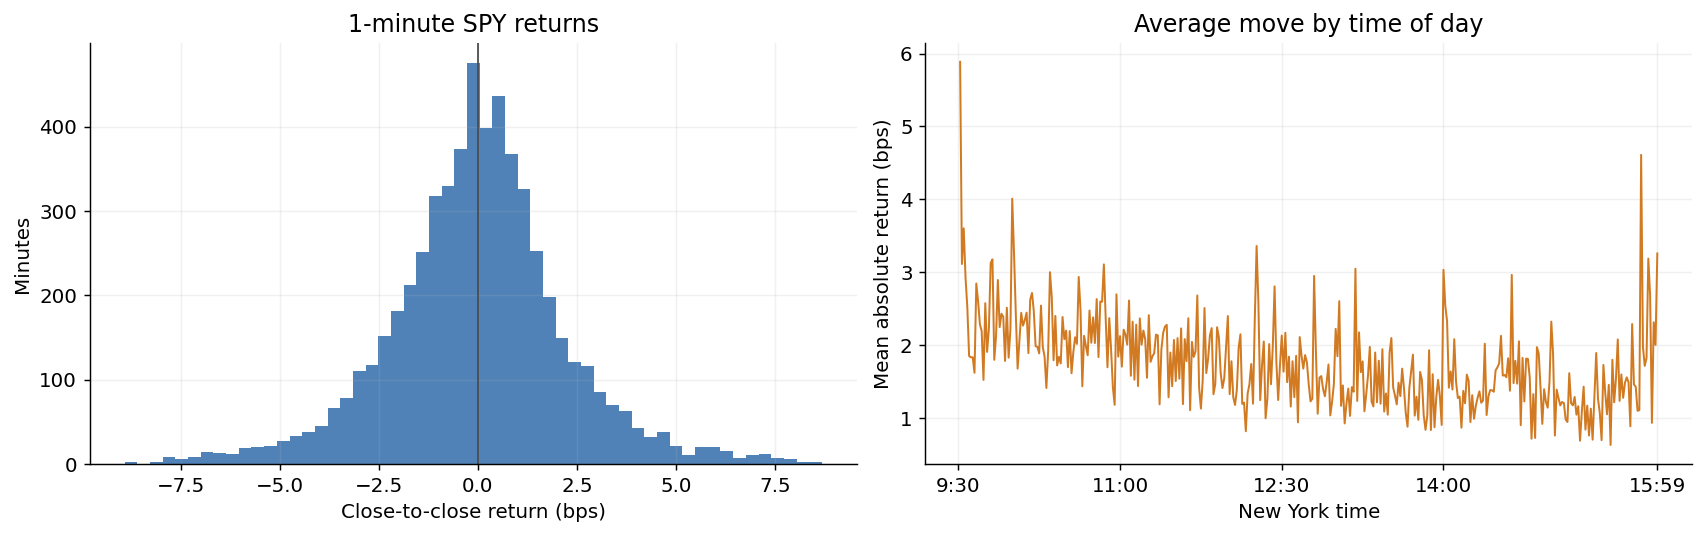

In [4]:
BLUE, ORANGE, GREEN, RED = "#2463a6", "#d17a22", "#238b68", "#bb4b52"

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
lo, hi = sample_returns.quantile([0.005, 0.995])
axes[0].hist(sample_returns, bins=55, range=(lo, hi), color=BLUE, alpha=0.8)
axes[0].axvline(0, color="0.3", lw=1)
axes[0].set(title="1-minute SPY returns", xlabel="Close-to-close return (bps)", ylabel="Minutes")

profile = bars.copy()
profile["clock_minute"] = profile.index.hour * 60 + profile.index.minute
profile["abs_return"] = within_day.abs() * 10_000
profile = profile.groupby("clock_minute")["abs_return"].mean()
axes[1].plot(profile.index, profile.values, color=ORANGE, lw=1.1)
axes[1].set(xticks=[570, 660, 750, 840, 959], xticklabels=["9:30", "11:00", "12:30", "14:00", "15:59"],
            title="Average move by time of day", xlabel="New York time", ylabel="Mean absolute return (bps)")
plt.show()

### Kalman filter: smooth the signal, keep the prices

I’m using a simple local-level Kalman filter on log price. It takes the previous estimate, adds uncertainty, then adjusts toward the newest close. In the update below, $K$ is the weight on the new observation.

$$P^-_t=P_{t-1}+Q,\qquad K_t=\frac{P^-_t}{P^-_t+R}$$
$$m_t=m_{t-1}+K_t(z_t-m_{t-1}),\qquad P_t=(1-K_t)P^-_t$$

Here $z_t$ is log price, $Q=10^{-8}$, and $R=4\times10^{-8}$. Those are fixed log-price variances, not estimates of the true noise. Their ratio makes the filter less jumpy than the close. I reset it at the start of each day so an overnight move doesn’t get treated as a minute of trading.

I chose Kalman over the usual centered Savitzky–Golay filter because a centered fit uses neighboring points on both sides. A trailing Savitzky–Golay fit would also be possible. Kalman is easier to keep causal here.

This step is smoothing, not deleting “bad” market moves. I don’t interpolate spikes away. The indicator uses the smoothed series, while the data summary keeps the observed prices.

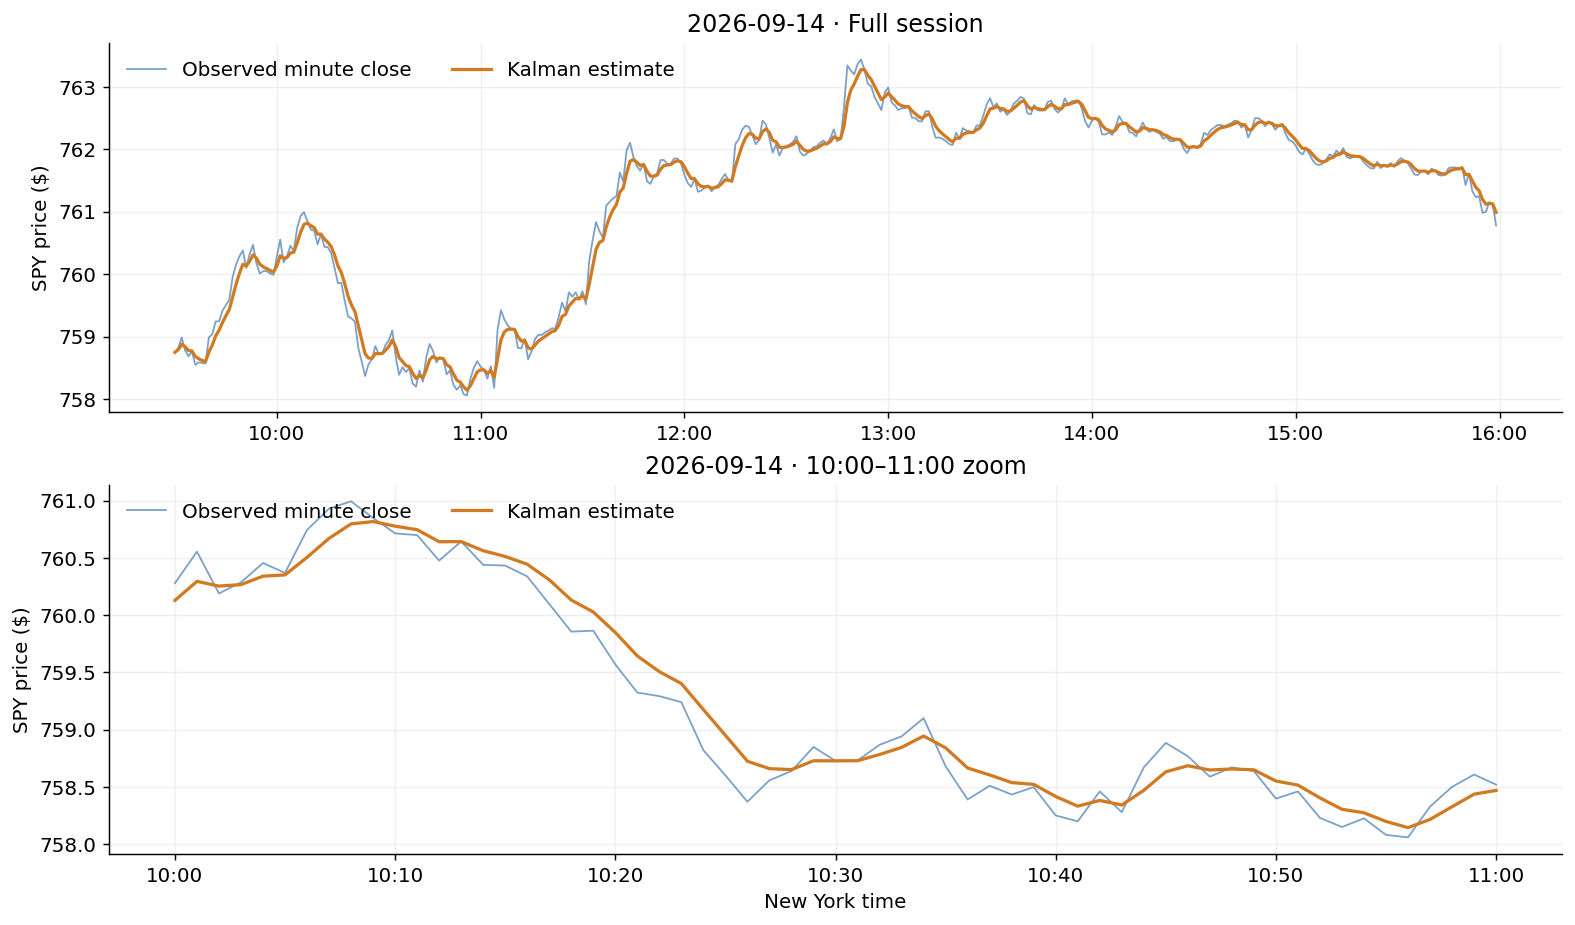

In [5]:
def kalman_price(price, process_var=1e-8, measurement_var=4e-8):
    z = np.log(np.asarray(price, dtype=float))
    estimate = np.empty(len(z))
    estimate[0], variance = z[0], measurement_var
    for i in range(1, len(z)):
        predicted_var = variance + process_var
        weight = predicted_var / (predicted_var + measurement_var)
        estimate[i] = estimate[i - 1] + weight * (z[i] - estimate[i - 1])
        variance = (1 - weight) * predicted_var
    return pd.Series(np.exp(estimate), index=price.index)

bars["kalman"] = bars.groupby(bars.index.normalize())["close"].transform(kalman_price)
example_day = sessions[0]  # Use the first day for the close-up.
example = bars.loc[bars.index.normalize() == example_day]
zoom = example.between_time("10:00", "11:00")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
for ax, sample, title in [(axes[0], example, "Full session"), (axes[1], zoom, "10:00–11:00 zoom")]:
    ax.plot(sample.index, sample["close"], color=BLUE, lw=1, alpha=0.6, label="Observed minute close")
    ax.plot(sample.index, sample["kalman"], color=ORANGE, lw=1.8, label="Kalman estimate")
    ax.set(title=f"{example_day.date()} · {title}", ylabel="SPY price ($)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=sample.index.tz))
    ax.legend(loc="upper left", frameon=False, ncol=2)
axes[1].set_xlabel("New York time")
plt.show()

## b) Turn the indicators into something we can correlate

My main input is the distance from the Kalman price to its EMA, divided by ATR. Above the EMA gives a positive value; below gives a negative one. Dividing by ATR makes a $0.20 gap mean less during a volatile stretch.

I also calculate centered RSI and the last price change divided by ATR. RSI is centered at 50. ATR alone has no long/short direction, so the ATR version needs a signed price change.

EMA uses 20 minutes. RSI and ATR use 14 minutes with Wilder’s recursive average, seeded with the first simple average. Flat prices give RSI 50; gains with no losses give 100. All three reset by session and stay unavailable during their warm-up.

In [6]:
def wilder_mean(values, length):
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.dropna()
    if len(valid) < length:
        return result
    average = valid.iloc[:length].mean()
    result.loc[valid.index[length - 1]] = average
    for time, value in valid.iloc[length:].items():
        average += (value - average) / length
        result.loc[time] = average
    return result


def make_features(price_bars, minutes=1):
    pieces = []
    ema_n = max(2, int(np.ceil(EMA_MINUTES / minutes)))
    rsi_n = max(2, int(np.ceil(RSI_MINUTES / minutes)))
    atr_n = max(2, int(np.ceil(ATR_MINUTES / minutes)))
    for _, day in price_bars.groupby(price_bars.index.normalize()):
        day = day.copy()
        day["kalman"] = kalman_price(day["close"], process_var=1e-8 * minutes)
        day["ema"] = day["kalman"].ewm(span=ema_n, adjust=False, min_periods=ema_n).mean()
        change = day["kalman"].diff()
        up = wilder_mean(change.clip(lower=0), rsi_n)
        down = wilder_mean(-change.clip(upper=0), rsi_n)
        day["rsi"] = 100 - 100 / (1 + up / down.replace(0, np.nan))
        day.loc[down.eq(0) & up.gt(0), "rsi"] = 100
        day.loc[down.eq(0) & up.eq(0), "rsi"] = 50

        previous_close = day["close"].shift(1)
        true_range = pd.concat([day["high"] - day["low"],
                                (day["high"] - previous_close).abs(),
                                (day["low"] - previous_close).abs()], axis=1).max(axis=1)
        day["atr"] = wilder_mean(true_range, atr_n)
        scale = day["atr"].replace(0, np.nan)
        day["ema_gap"] = (day["kalman"] - day["ema"]) / scale
        day["rsi_centered"] = (day["rsi"] - 50) / 50
        day["atr_move"] = change / scale
        pieces.append(day)
    return pd.concat(pieces)

features = make_features(bars)
FEATURES = {"ema_gap": "EMA distance / ATR", "rsi_centered": "Centered RSI", "atr_move": "Price change / ATR"}
display(features[["ema", "rsi", "atr", *FEATURES]].describe().round(3))

,ema,rsi,atr,ema_gap,rsi_centered,atr_move
count,5565.000,5640.000,5655.000,5565.000,5640.000,5655.000
mean,765.306,50.552,0.355,0.019,0.011,0.000
std,4.949,19.842,0.251,0.909,0.397,0.258
min,751.325,0.698,0.113,-3.667,-0.986,-1.239
25%,761.192,35.634,0.230,-0.575,-0.287,-0.158
50%,765.365,51.721,0.304,0.052,0.034,0.001
75%,768.961,64.965,0.416,0.612,0.299,0.155
max,774.600,95.637,5.772,3.237,0.913,1.808


### Correlation with the next minute

Correlating price with its own EMA would mostly tell me that two price lines move together. I want to see whether the indicator relates to a return that comes after it.

Let $x_t$ be the indicator at the close of bar $t$, and let $r_t=C_t/C_{t-1}-1$ be the latest minute return. Once bar $t$ finishes, I can calculate

$$\rho_t=\operatorname{Corr}(x_{i-1},r_i),\quad i=t-59,\ldots,t.$$

That is the previous indicator paired with the next observed return, over 60 complete pairs within the same session. The code uses `feature.shift(1)` so the indicator comes first. I need all 60 pairs before allowing a signal.

For the scatterplot only, I line up each indicator with the following minute’s return. That forward return is descriptive and never enters the signal calculation.

Positive correlation means the feature and the next return recently lined up. Negative correlation means they tended to oppose each other. A correlation near zero gives me no reason to trade. The 0.10 cutoff is a simple design choice, not a significance test.

In [7]:
def add_correlations(feature_frame):
    pieces = []
    for _, day in feature_frame.groupby(feature_frame.index.normalize()):
        day = day.copy()
        known_return = day["close"].pct_change(fill_method=None)
        for name in FEATURES:
            day[f"corr_{name}"] = day[name].shift(1).rolling(
                CORR_MINUTES, min_periods=CORR_MINUTES).corr(known_return)
        # This forward value is just for describing the relationship on a plot.
        day["future_return"] = day["close"].shift(-1) / day["close"] - 1
        pieces.append(day)
    return pd.concat(pieces)

features = add_correlations(features)
correlation_rows = []
for name, label in FEATURES.items():
    sample = features[[name, "future_return"]].dropna()
    correlation_rows.append({"input": label, "pairs": len(sample),
                             "correlation with next return": sample[name].corr(sample["future_return"])})
correlation_table = pd.DataFrame(correlation_rows).set_index("input")
display(correlation_table.round(4))

,pairs,correlation with next return
input,,
EMA distance / ATR,5550,-0.0076
Centered RSI,5625,-0.0105
Price change / ATR,5640,0.0386


### Does the relationship show up on a plot?

The dots below are the observations from all 15 sessions. The orange points are average returns in ten equal-count feature bins. I’m keeping the scatter faint so the averages are readable. A messy, mostly flat cloud is useful information too; it doesn’t need a story forced onto it.

The following chart uses the same fixed example day. Price, RSI, ATR, and correlation get separate axes because their units are different.

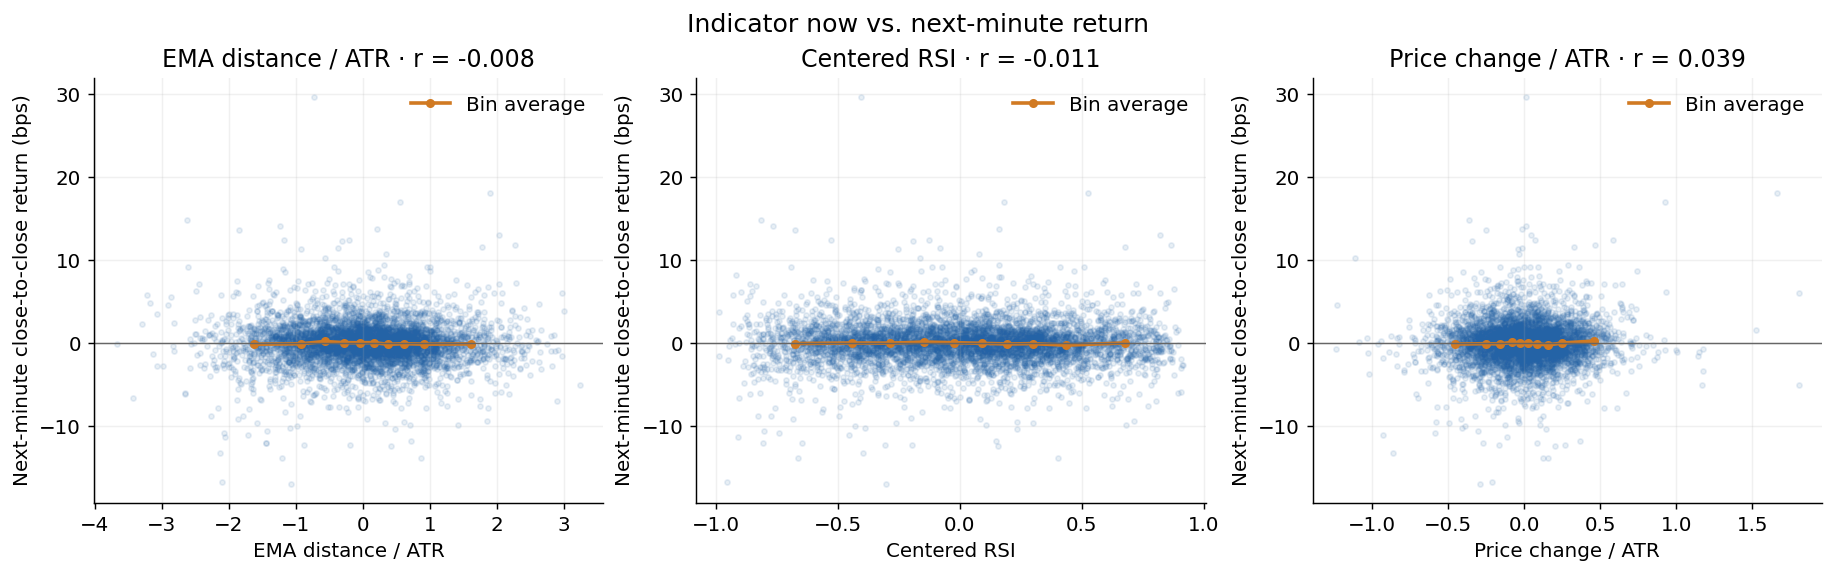

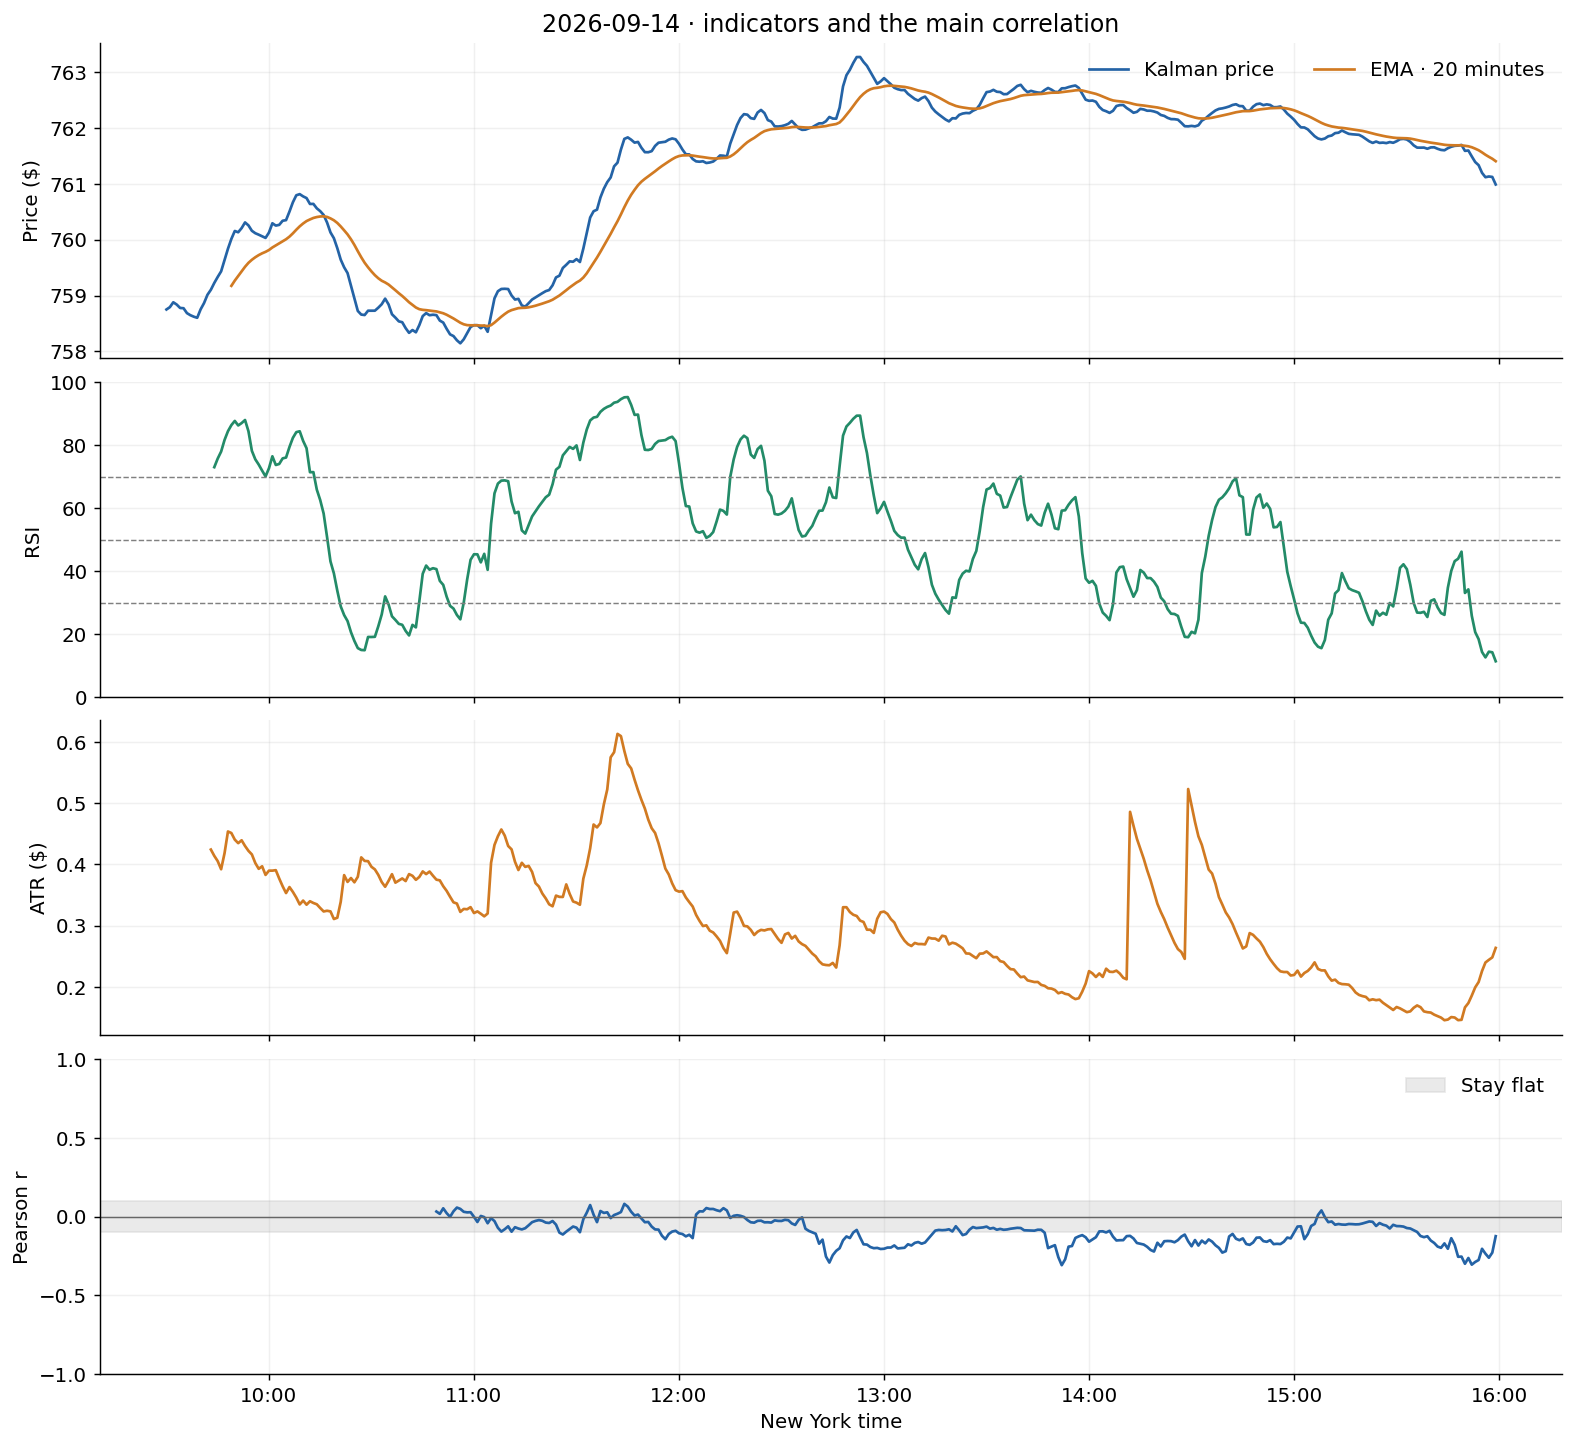

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
for ax, (name, label) in zip(axes, FEATURES.items()):
    sample = features[[name, "future_return"]].dropna().copy()
    sample["return_bps"] = sample["future_return"] * 10_000
    ax.scatter(sample[name], sample["return_bps"], s=8, alpha=0.10, color=BLUE, rasterized=True)
    sample["bin"] = pd.qcut(sample[name], 10, duplicates="drop")
    averages = sample.groupby("bin", observed=True)[[name, "return_bps"]].mean()
    ax.plot(averages[name], averages["return_bps"], "o-", color=ORANGE, lw=2, ms=4, label="Bin average")
    ax.axhline(0, color="0.4", lw=0.8)
    rho = sample[name].corr(sample["future_return"])
    ax.set(title=f"{label} · r = {rho:.3f}", xlabel=label, ylabel="Next-minute close-to-close return (bps)")
    ax.legend(frameon=False, loc="upper right")
fig.suptitle("Indicator now vs. next-minute return", fontsize=14)
plt.show()

example_features = features.loc[features.index.normalize() == example_day]
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
axes[0].plot(example_features.index, example_features["kalman"], color=BLUE, label="Kalman price")
axes[0].plot(example_features.index, example_features["ema"], color=ORANGE, label="EMA · 20 minutes")
axes[0].set(ylabel="Price ($)", title=f"{example_day.date()} · indicators and the main correlation")
axes[0].legend(frameon=False, ncol=2)
axes[1].plot(example_features.index, example_features["rsi"], color=GREEN)
for level in [30, 50, 70]:
    axes[1].axhline(level, color="0.5", ls="--", lw=0.8)
axes[1].set(ylabel="RSI", ylim=(0, 100))
axes[2].plot(example_features.index, example_features["atr"], color=ORANGE)
axes[2].set(ylabel="ATR ($)")
axes[3].plot(example_features.index, example_features["corr_ema_gap"], color=BLUE)
axes[3].axhspan(-CORR_CUTOFF, CORR_CUTOFF, color="0.8", alpha=0.4, label="Stay flat")
axes[3].axhline(0, color="0.4", lw=0.8)
axes[3].set(ylabel="Pearson r", ylim=(-1, 1), xlabel="New York time")
axes[3].legend(frameon=False)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=example_features.index.tz))
plt.show()

### The proposed trading rule

EMA distance is the main version. At each completed minute, I calculate the 60-minute correlation. If its absolute value is below 0.10, or there aren’t enough observations yet, the signal is flat. Otherwise:

| Current EMA gap | Positive correlation | Negative correlation |
| --- | --- | --- |
| Above the EMA | Long | Short |
| Below the EMA | Short | Long |

In code, that’s the sign of `feature × correlation`. A gap of exactly zero also gives a flat signal. The RSI and ATR-scaled versions use the same logic, so the input can be changed without changing the rule.

A signal is available only after its minute bar closes. Any later implementation would have to trade after that point and account for execution costs. For now, the output is just a proposed direction: +1 long, −1 short, and 0 flat. There are no simulated orders or profits here.

In [9]:
def make_signals(feature_frame, feature="ema_gap", cutoff=CORR_CUTOFF):
    if feature not in FEATURES:
        raise ValueError(f"Choose one of {list(FEATURES)}")
    rho = feature_frame[f"corr_{feature}"]
    signal = np.sign(feature_frame[feature] * rho)
    return signal.where(rho.abs().ge(cutoff), 0).fillna(0).astype(int).rename("signal")

features["signal"] = make_signals(features)
signal_labels = features["signal"].map({-1: "short", 0: "flat", 1: "long"})
print("Proposed EMA signals; these are not executed trades:")
display(signal_labels.value_counts().reindex(["long", "flat", "short"], fill_value=0).rename("minutes").to_frame())

example_signals = features.loc[features.index.normalize() == example_day]
example_rows = example_signals.loc[example_signals["corr_ema_gap"].notna()]
display(example_rows[["kalman", "ema", "atr", "ema_gap", "corr_ema_gap", "signal"]].head(12).round(4))

Proposed EMA signals; these are not executed trades:


,minutes
signal,
long,1467
flat,2753
short,1630


,kalman,ema,atr,ema_gap,corr_ema_gap,signal
bar_time,,,,,,
2026-09-14 10:49:00-04:00,758.6489,758.7153,0.3750,-0.1772,0.0326,0
2026-09-14 10:50:00-04:00,758.5508,758.6996,0.3739,-0.3982,0.0177,0
2026-09-14 10:51:00-04:00,758.5153,758.6821,0.3643,-0.4577,0.0530,0
2026-09-14 10:52:00-04:00,758.4035,758.6555,0.3567,-0.7068,0.0223,0
2026-09-14 10:53:00-04:00,758.3040,758.6221,0.3471,-0.9162,-0.0012,0
2026-09-14 10:54:00-04:00,758.2732,758.5888,0.3380,-0.9339,0.0340,0
2026-09-14 10:55:00-04:00,758.1978,758.5516,0.3360,-1.0531,0.0577,0
2026-09-14 10:56:00-04:00,758.1435,758.5127,0.3224,-1.1454,0.0493,0
2026-09-14 10:57:00-04:00,758.2154,758.4844,0.3272,-0.8223,0.0309,0


### Check that the signal only uses what’s known

I change the later part of one session and recalculate it. Earlier indicators, correlations, and signals should stay the same. I also check a few long/short/flat cases by hand. These are code checks, not tests of whether the strategy makes money.

In [10]:
cut = 150
original_day = bars.loc[bars.index.normalize() == example_day].copy()
changed_day = original_day.copy()
price_columns = ["open", "high", "low", "close", "vwap"]
changed_day.loc[changed_day.index[cut:], price_columns] *= 1.05
original_features = add_correlations(make_features(original_day))
changed_features = add_correlations(make_features(changed_day))
causal_columns = ["kalman", "ema", "rsi", "atr", *FEATURES, *[f"corr_{name}" for name in FEATURES]]
pd.testing.assert_frame_equal(original_features[causal_columns].iloc[:cut],
                              changed_features[causal_columns].iloc[:cut])
pd.testing.assert_series_equal(make_signals(original_features).iloc[:cut],
                               make_signals(changed_features).iloc[:cut])

changed_target = features.copy()
changed_target["future_return"] = 999
pd.testing.assert_series_equal(make_signals(changed_target), features["signal"])
assert features.loc[features["corr_ema_gap"].isna(), "signal"].eq(0).all()

# A positive/negative correlation should change the direction as written above.
toy = features.iloc[:6].copy()
toy["ema_gap"] = [1, -1, 1, -1, 1, np.nan]
toy["corr_ema_gap"] = [0.3, 0.3, -0.3, -0.3, 0.05, 0.3]
assert make_signals(toy).tolist() == [1, -1, -1, 1, 0, 0]

for shape, expected_rsi in [("flat", 50), ("up", 100), ("down", 0)]:
    toy_price = original_day.iloc[:40].copy()
    price = np.full(40, 100.0) if shape == "flat" else 100 + np.arange(40) * (1 if shape == "up" else -1)
    for column in price_columns:
        toy_price[column] = price
    toy_price["high"], toy_price["low"] = price + 0.1, price - 0.1
    assert np.isclose(make_features(toy_price)["rsi"].iloc[-1], expected_rsi)
print("Passed: future-data check, warm-up, signal direction, and RSI edge cases.")

Passed: future-data check, warm-up, signal direction, and RSI edge cases.


### What I’d take from this

The raw downloads were the same file twice, so I used one copy. After filtering, I have 5,850 complete minute bars across 15 sessions. The Kalman estimate is less jumpy than the close, but it still lags when price moves quickly. Smoothing helps me read the indicator; it doesn’t prove that the indicator predicts returns.

Across the full sample, the next-minute return correlations are about −0.008 for EMA distance, −0.011 for centered RSI, and 0.039 for the ATR-scaled move. Those are all close to zero, so I don’t see a strong overall linear relationship here. A rolling correlation can change sign during a day, which is why the rule can switch between following and opposing the indicator. When the relationship is small, it stays flat.

That gives me a simple algorithm for part b. I’m stopping at the signal design for this homework. Whether it earns money after costs is a separate question to test later.

### References for the implementation

The assignment wording and the supplied CSVs are the starting point. These links are for checking the technical details:

- [NYSE Daily TAQ specification, trade fields on pages 17–20](https://www.nyse.com/publicdocs/nyse/data/Daily_TAQ_Client_Spec_v4.3.pdf): timestamps, correction flags, and sale-condition codes.
- [pandas window calculations](https://pandas.pydata.org/docs/user_guide/window.html): recursive EMA and rolling correlation.
- [SciPy Savitzky–Golay filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html): window and edge handling for the alternative smoother.

The Kalman recursion and strategy timing are written out above, so the trading rule can be followed without those links.